<a href="https://colab.research.google.com/github/siddharthachhabra/GPT2-From-Scratch/blob/main/GPT_2_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import urllib.request
import re
import tiktoken

url = ("https://raw.githubusercontent.com/rasbt/"
 "LLMs-from-scratch/main/ch02/01_main-chapter-code/"
 "the-verdict.txt")
file_path = "the-verdict.txt"
urllib.request.urlretrieve(url, file_path)

with open("the-verdict.txt", "r", encoding="utf-8") as f:
 raw_text = f.read()

# clean data
preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', raw_text)
preprocessed = [item.strip() for item in preprocessed if item.strip()]

# dictionary
all_tokens = sorted(set(preprocessed))
all_tokens.extend(["<|endoftext|>", "<|unk|>"])
vocab = {token:integer for integer,token in enumerate(all_tokens)}
print(len(vocab.items()))

1132


In [9]:
class SimpleTokenizerV2:
    def __init__(self, vocab):
        self.str_to_int = vocab
        self.int_to_str = {v: k for k, v in vocab.items()}

    def encode(self, text):
        preprocessed = re.split(r'([,.?_!"()\']|--|\s)', text)
        preprocessed = [
            item.strip() for item in preprocessed if item.strip()
        ]
        preprocessed = [item if item in self.str_to_int
                      else "<|unk|>" for item in preprocessed]
        ids = [self.str_to_int[s] for s in preprocessed]
        return ids

    def decode(self, ids):
        text = " ".join([self.int_to_str[i] for i in ids])
        text = re.sub(r'\s+([,.?!"()\'])', r'\1', text)
        return text

In [10]:
tokenizer = tiktoken.get_encoding("gpt2")
enc_text = tokenizer.encode(raw_text)
print(len(enc_text))

5145


In [11]:
import torch
from torch.utils.data import Dataset, DataLoader

class GPTDatasetV1(Dataset):
  def __init__(self, txt, tokenizer, max_length, stride):
     self.input_ids = []
     self.target_ids = []
     token_ids = tokenizer.encode(txt)
     for i in range(0, len(token_ids) - max_length, stride):
       input_chunk = token_ids[i:i + max_length]
       target_chunk = token_ids[i + 1: i + max_length + 1]
       self.input_ids.append(torch.tensor(input_chunk))
       self.target_ids.append(torch.tensor(target_chunk))

  def __len__(self):
    return len(self.input_ids)

  def __getitem__(self, idx):
    return self.input_ids[idx], self.target_ids[idx]

def create_dataloader_v1(txt, batch_size=4, max_length=256,
                           stride=128, shuffle=True, drop_last=True,
                           num_workers=0):
     tokenizer = tiktoken.get_encoding("gpt2")
     dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)
     dataloader = DataLoader(
       dataset,
       batch_size=batch_size,
       shuffle=shuffle,
       drop_last=drop_last,
      num_workers=num_workers)
     return dataloader

In [12]:
torch.manual_seed(123)
vocab_size = 50257
output_dim = 256
token_embedding_layer = torch.nn.Embedding(vocab_size, output_dim)
max_length = 4
dataloader = create_dataloader_v1(
 raw_text, batch_size=8, max_length=max_length,
 stride=max_length, shuffle=False
)
data_iter = iter(dataloader)
inputs, targets = next(data_iter)
token_embeddings = token_embedding_layer(inputs)
context_length = max_length
pos_embedding_layer = torch.nn.Embedding(context_length, output_dim)
pos_embeddings = pos_embedding_layer(torch.arange(context_length))
input_embeddings = token_embeddings + pos_embeddings
print(input_embeddings.shape)

torch.Size([8, 4, 256])


In [13]:
import torch
x = [0.43, 0.15, 0.89]
y = [0.55, 0.87, 0.66]
print(torch.dot(torch.tensor(x), torch.tensor(y)))

tensor(0.9544)


In [14]:
import torch
x = [0.43, 0.15, 0.89]
y = [0.55, 0.87, 0.66]
print(torch.dot(torch.tensor(x), torch.tensor(y)))

tensor(0.9544)


In [15]:
import torch
import torch.nn as nn

inputs = torch.tensor(
 [[0.43, 0.15, 0.89], # Your (x^1)
 [0.55, 0.87, 0.66],  # journey (x^2)
 [0.57, 0.85, 0.64],  # starts (x^3)
 [0.22, 0.58, 0.33],  # with (x^4)
 [0.77, 0.25, 0.10],  # one (x^5)
 [0.05, 0.80, 0.55]]  # step (x^6)
)
d_in = inputs.shape[1]
d_out = 2

class SelfAttention_v1(nn.Module):
  def __init__(self, d_in, d_out):
    super().__init__()
    self.W_query = nn.Parameter(torch.rand(d_in, d_out))
    self.W_key = nn.Parameter(torch.rand(d_in, d_out))
    self.W_value = nn.Parameter(torch.rand(d_in, d_out))

  def forward(self, x):
    keys = x @ self.W_key
    queries = x @ self.W_query
    values = x @ self.W_value
    attn_scores = queries @ keys.T # omega
    attn_weights = torch.softmax(
      attn_scores / keys.shape[-1]**0.5, dim=-1
    )
    context_vec = attn_weights @ values
    return context_vec

class SelfAttention_v2(nn.Module):
  def __init__(self, d_in, d_out, qkv_bias=False):
    super().__init__()
    self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

  def forward(self, x):
    keys = self.W_key(x)
    queries = self.W_query(x)
    values = self.W_value(x)
    attn_scores = queries @ keys.T
    attn_weights = torch.softmax(
      attn_scores / keys.shape[-1]**0.5, dim=-1
    )
    context_vec = attn_weights @ values
    return context_vec

torch.manual_seed(789)
sa_v2 = SelfAttention_v2(d_in, d_out)
print(sa_v2(inputs))

tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)


In [16]:
class CausalAttention(nn.Module):
  def __init__(self, d_in, d_out, context_length,
    dropout, qkv_bias=False):
    super().__init__()
    self.d_out = d_out
    self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.dropout = nn.Dropout(dropout)
    self.register_buffer(
      'mask',
      torch.triu(
        torch.ones(context_length, context_length),
        diagonal=1
      )
   )

  def forward(self, x):
    b, num_tokens, d_in = x.shape
    keys = self.W_key(x)
    queries = self.W_query(x)
    values = self.W_value(x)
    attn_scores = queries @ keys.transpose(1, 2)
    attn_scores.masked_fill_(
      self.mask.bool()[:num_tokens, :num_tokens], -torch.inf
    )
    attn_weights = torch.softmax(
      attn_scores / keys.shape[-1]**0.5, dim=-1
    )
    attn_weights = self.dropout(attn_weights)
    context_vec = attn_weights @ values
    return context_vec

torch.manual_seed(123)
batch = torch.stack((inputs, inputs), dim=0)
context_length = batch.shape[1]
ca = CausalAttention(d_in, d_out, context_length, 0.0)
context_vecs = ca(batch)
print("context_vecs.shape:", context_vecs.shape)

context_vecs.shape: torch.Size([2, 6, 2])


In [17]:
import torch
import torch.nn as nn

inputs = torch.tensor(
 [[0.43, 0.15, 0.89], # Your (x^1)
 [0.55, 0.87, 0.66],  # journey (x^2)
 [0.57, 0.85, 0.64],  # starts (x^3)
 [0.22, 0.58, 0.33],  # with (x^4)
 [0.77, 0.25, 0.10],  # one (x^5)
 [0.05, 0.80, 0.55]]  # step (x^6)
)
d_in = inputs.shape[1]
d_out = 2

class SelfAttention_v1(nn.Module):
  def __init__(self, d_in, d_out):
    super().__init__()
    self.W_query = nn.Parameter(torch.rand(d_in, d_out))
    self.W_key = nn.Parameter(torch.rand(d_in, d_out))
    self.W_value = nn.Parameter(torch.rand(d_in, d_out))

  def forward(self, x):
    keys = x @ self.W_key
    queries = x @ self.W_query
    values = x @ self.W_value
    attn_scores = queries @ keys.T # omega
    attn_weights = torch.softmax(
      attn_scores / keys.shape[-1]**0.5, dim=-1
    )
    context_vec = attn_weights @ values
    return context_vec

class SelfAttention_v2(nn.Module):
  def __init__(self, d_in, d_out, qkv_bias=False):
    super().__init__()
    self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

  def forward(self, x):
    keys = self.W_key(x)
    queries = self.W_query(x)
    values = self.W_value(x)
    attn_scores = queries @ keys.T
    attn_weights = torch.softmax(
      attn_scores / keys.shape[-1]**0.5, dim=-1
    )
    context_vec = attn_weights @ values
    return context_vec

torch.manual_seed(789)
sa_v2 = SelfAttention_v2(d_in, d_out)
print(sa_v2(inputs))

tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)


In [18]:
import torch
import torch.nn as nn

inputs = torch.tensor(
 [[0.43, 0.15, 0.89], # Your (x^1)
 [0.55, 0.87, 0.66],  # journey (x^2)
 [0.57, 0.85, 0.64],  # starts (x^3)
 [0.22, 0.58, 0.33],  # with (x^4)
 [0.77, 0.25, 0.10],  # one (x^5)
 [0.05, 0.80, 0.55]]  # step (x^6)
)
d_in = inputs.shape[1]
d_out = 2

class SelfAttention_v1(nn.Module):
  def __init__(self, d_in, d_out):
    super().__init__()
    self.W_query = nn.Parameter(torch.rand(d_in, d_out))
    self.W_key = nn.Parameter(torch.rand(d_in, d_out))
    self.W_value = nn.Parameter(torch.rand(d_in, d_out))

  def forward(self, x):
    keys = x @ self.W_key
    queries = x @ self.W_query
    values = x @ self.W_value
    attn_scores = queries @ keys.T # omega
    attn_weights = torch.softmax(
      attn_scores / keys.shape[-1]**0.5, dim=-1
    )
    context_vec = attn_weights @ values
    return context_vec

class SelfAttention_v2(nn.Module):
  def __init__(self, d_in, d_out, qkv_bias=False):
    super().__init__()
    self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

  def forward(self, x):
    keys = self.W_key(x)
    queries = self.W_query(x)
    values = self.W_value(x)
    attn_scores = queries @ keys.T
    attn_weights = torch.softmax(
      attn_scores / keys.shape[-1]**0.5, dim=-1
    )
    context_vec = attn_weights @ values
    return context_vec

torch.manual_seed(789)
sa_v2 = SelfAttention_v2(d_in, d_out)
print(sa_v2(inputs))

tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)


In [19]:
import torch
import torch.nn as nn

inputs = torch.tensor(
 [[0.43, 0.15, 0.89], # Your (x^1)
 [0.55, 0.87, 0.66],  # journey (x^2)
 [0.57, 0.85, 0.64],  # starts (x^3)
 [0.22, 0.58, 0.33],  # with (x^4)
 [0.77, 0.25, 0.10],  # one (x^5)
 [0.05, 0.80, 0.55]]  # step (x^6)
)
d_in = inputs.shape[1]
d_out = 2

class SelfAttention_v1(nn.Module):
  def __init__(self, d_in, d_out):
    super().__init__()
    self.W_query = nn.Parameter(torch.rand(d_in, d_out))
    self.W_key = nn.Parameter(torch.rand(d_in, d_out))
    self.W_value = nn.Parameter(torch.rand(d_in, d_out))

  def forward(self, x):
    keys = x @ self.W_key
    queries = x @ self.W_query
    values = x @ self.W_value
    attn_scores = queries @ keys.T # omega
    attn_weights = torch.softmax(
      attn_scores / keys.shape[-1]**0.5, dim=-1
    )
    context_vec = attn_weights @ values
    return context_vec

class SelfAttention_v2(nn.Module):
  def __init__(self, d_in, d_out, qkv_bias=False):
    super().__init__()
    self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

  def forward(self, x):
    keys = self.W_key(x)
    queries = self.W_query(x)
    values = self.W_value(x)
    attn_scores = queries @ keys.T
    attn_weights = torch.softmax(
      attn_scores / keys.shape[-1]**0.5, dim=-1
    )
    context_vec = attn_weights @ values
    return context_vec

torch.manual_seed(789)
sa_v2 = SelfAttention_v2(d_in, d_out)
print(sa_v2(inputs))

tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)


In [20]:
# Start building from this.
import torch
import torch.nn as nn

inputs = torch.tensor(
 [[0.43, 0.15, 0.89], # Your (x^1)
 [0.55, 0.87, 0.66],  # journey (x^2)
 [0.57, 0.85, 0.64],  # starts (x^3)
 [0.22, 0.58, 0.33],  # with (x^4)
 [0.77, 0.25, 0.10],  # one (x^5)
 [0.05, 0.80, 0.55]]  # step (x^6)
)

class MultiHeadAttention(nn.Module):
  def __init__(self, d_in, d_out,
      context_length, dropout, num_heads, qkv_bias=False):
    super().__init__()
    assert (d_out % num_heads == 0), \
      "d_out must be divisible by num_heads"
    self.d_out = d_out
    self.num_heads = num_heads
    self.head_dim = d_out // num_heads
    self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.out_proj = nn.Linear(d_out, d_out)
    self.dropout = nn.Dropout(dropout)
    self.register_buffer(
      "mask",
      torch.triu(torch.ones(context_length, context_length),
      diagonal=1)
    )

  def forward(self, x):
    b, num_tokens, d_in = x.shape
    keys = self.W_key(x)
    queries = self.W_query(x)
    values = self.W_value(x)
    keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
    values = values.view(b, num_tokens, self.num_heads, self.head_dim)
    queries = queries.view(
      b, num_tokens, self.num_heads, self.head_dim
    )
    keys = keys.transpose(1, 2)
    queries = queries.transpose(1, 2)
    values = values.transpose(1, 2)
    attn_scores = queries @ keys.transpose(2, 3)
    mask_bool = self.mask.bool()[:num_tokens, :num_tokens]
    attn_scores.masked_fill_(mask_bool, -torch.inf)
    attn_weights = torch.softmax(
    attn_scores / keys.shape[-1]**0.5, dim=-1)
    attn_weights = self.dropout(attn_weights)
    context_vec = (attn_weights @ values).transpose(1, 2)
    context_vec = context_vec.contiguous().view(
      b, num_tokens, self.d_out
    )
    context_vec = self.out_proj(context_vec)
    return context_vec

torch.manual_seed(123)
batch = torch.stack((inputs, inputs), dim=0)
batch_size, context_length, d_in = batch.shape
d_out = 2
mha = MultiHeadAttention(d_in, d_out, context_length, 0.0, num_heads=2)
context_vecs = mha(batch)
print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

tensor([[[0.3190, 0.4858],
         [0.2943, 0.3897],
         [0.2856, 0.3593],
         [0.2693, 0.3873],
         [0.2639, 0.3928],
         [0.2575, 0.4028]],

        [[0.3190, 0.4858],
         [0.2943, 0.3897],
         [0.2856, 0.3593],
         [0.2693, 0.3873],
         [0.2639, 0.3928],
         [0.2575, 0.4028]]], grad_fn=<ViewBackward0>)
context_vecs.shape: torch.Size([2, 6, 2])


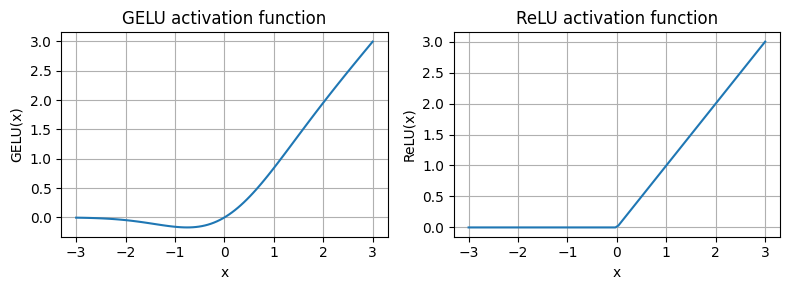

In [21]:
class GELU(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self, x):
    return 0.5 * x * (1 + torch.tanh(
      torch.sqrt(torch.tensor(2.0 / torch.pi)) *
      (x + 0.044715 * torch.pow(x, 3))
    ))

import matplotlib.pyplot as plt
gelu, relu = GELU(), nn.ReLU()
x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)
plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
  plt.subplot(1, 2, i)
  plt.plot(x, y)
  plt.title(f"{label} activation function")
  plt.xlabel("x")
  plt.ylabel(f"{label}(x)")
  plt.grid(True)
plt.tight_layout()
plt.show()

In [22]:
GPT_CONFIG_124M = {
 "vocab_size": 50257, # Vocabulary size
 "context_length": 256, # Context length
 "emb_dim": 768, # Embedding dimension
 "n_heads": 12, # Number of attention heads
 "n_layers": 12, # Number of layers
 "drop_rate": 0.1, # Dropout rate
 "qkv_bias": False # Query-Key-Value bias
}

class FeedForward(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.layers = nn.Sequential(
      nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
      GELU(),
      nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
    )

  def forward(self, x):
    return self.layers(x)


In [23]:
import torch
import torch.nn as nn

class GPTModel(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
    self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
    self.drop_emb = nn.Dropout(cfg["drop_rate"])

    self.trf_blocks = nn.Sequential(
    *[TransformerBlock(cfg)
       for _ in range(cfg["n_layers"])]
    )

    self.final_norm = LayerNorm(cfg["emb_dim"])
    self.out_head = nn.Linear(
      cfg["emb_dim"], cfg["vocab_size"], bias=False
    )

  def forward(self, in_idx):
    batch_size, seq_len = in_idx.shape
    tok_embeds = self.tok_emb(in_idx)
    pos_embeds = self.pos_emb(
      torch.arange(seq_len, device=in_idx.device)
    )
    x = tok_embeds + pos_embeds
    x = self.drop_emb(x)
    x = self.trf_blocks(x)
    x = self.final_norm(x)
    logits = self.out_head(x)
    return logits

class TransformerBlock(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.att = MultiHeadAttention(
      d_in=cfg["emb_dim"],
      d_out=cfg["emb_dim"],
      context_length=cfg["context_length"],
      num_heads=cfg["n_heads"],
      dropout=cfg["drop_rate"],
      qkv_bias=cfg["qkv_bias"])
    self.ff = FeedForward(cfg)
    self.norm1 = LayerNorm(cfg["emb_dim"])
    self.norm2 = LayerNorm(cfg["emb_dim"])
    self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

  def forward(self, x):
    shortcut = x
    x = self.norm1(x)
    x = self.att(x)
    x = self.drop_shortcut(x)
    x = x + shortcut
    shortcut = x
    x = self.norm2(x)
    x = self.ff(x)
    x = self.drop_shortcut(x)
    x = x + shortcut
    return x

class LayerNorm(nn.Module):
  def __init__(self, emb_dim):
    super().__init__()
    self.eps = 1e-5
    self.scale = nn.Parameter(torch.ones(emb_dim))
    self.shift = nn.Parameter(torch.zeros(emb_dim))

  def forward(self, x):
    mean = x.mean(dim=-1, keepdim=True)
    var = x.var(dim=-1, keepdim=True, unbiased=False)
    norm_x = (x - mean) / torch.sqrt(var + self.eps)
    return self.scale * norm_x + self.shift

import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"
batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
out = model(batch)
print("Input batch:\n", batch)
print("\nOutput shape:", out.shape)
print(out)

Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[-1.7955e-01,  2.8515e-01, -7.6131e-01,  ..., -4.8374e-01,
          -4.2503e-01, -1.7187e-01],
         [-6.2581e-01, -3.7480e-01, -9.7020e-01,  ...,  1.9168e-01,
          -1.3234e+00, -2.7643e-01],
         [ 5.1744e-01,  1.3866e-01,  2.4886e-01,  ...,  3.5054e-01,
          -7.7531e-02, -8.0041e-02],
         [-2.5664e-01, -6.9693e-01, -9.9479e-01,  ..., -4.4732e-02,
           6.1772e-02,  1.3467e-01]],

        [[-2.2379e-01,  1.1651e-01, -9.9836e-01,  ..., -1.5730e-01,
          -4.4800e-01, -2.8646e-02],
         [-8.7227e-01, -3.9389e-01, -1.1099e+00,  ...,  3.3035e-01,
          -9.2395e-02, -1.8701e-05],
         [ 4.5988e-01, -1.4274e-01, -1.2227e-01,  ...,  2.7490e-01,
           5.8297e-02, -8.9930e-02],
         [-6.2163e-01, -4.4854e-01, -4.7675e-01,  ..., -3.6519e-01,
           3.4402e-01, -3.8154e-01]]], grad_fn=<UnsafeViewBackward0>)


In [24]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")
total_params_gpt2 = (
  total_params - sum(p.numel()
  for p in model.out_head.parameters())
)
print(f"Number of trainable parameters "
  f"considering weight tying: {total_params_gpt2:,}"
)
total_size_bytes = total_params * 4
total_size_mb = total_size_bytes / (1024 * 1024)
print(f"Total size of the model: {total_size_mb:.2f} MB")

Total number of parameters: 162,419,712
Number of trainable parameters considering weight tying: 123,822,336
Total size of the model: 619.58 MB


In [25]:
def generate_text_simple(model, idx,
    max_new_tokens, context_size):
  for _ in range(max_new_tokens):
    idx_cond = idx[:, -context_size:]
    with torch.no_grad():
      logits = model(idx_cond)

    logits = logits[:, -1, :]
    probas = torch.softmax(logits, dim=-1)
    idx_next = torch.argmax(probas, dim=-1, keepdim=True)
    idx = torch.cat((idx, idx_next), dim=1)
  return idx

start_context = "Hello, I am"
encoded = tokenizer.encode(start_context)
print("encoded:", encoded)
encoded_tensor = torch.tensor(encoded).unsqueeze(0)
print("encoded_tensor.shape:", encoded_tensor.shape)


model.eval()
out = generate_text_simple(
  model=model,
  idx=encoded_tensor,
  max_new_tokens=6,
  context_size=GPT_CONFIG_124M["context_length"]
)
print("Output:", out)
print("Output length:", len(out[0]))
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

encoded: [15496, 11, 314, 716]
encoded_tensor.shape: torch.Size([1, 4])
Output: tensor([[15496,    11,   314,   716, 13240, 11381,  4307,  7640, 16620, 34991]])
Output length: 10
Hello, I am Laur inhab DistrinetalkQueue


In [26]:
import tiktoken

def text_to_token_ids(text, tokenizer):
  encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
  encoded_tensor = torch.tensor(encoded).unsqueeze(0)
  return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
  flat = token_ids.squeeze(0)
  return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")
token_ids = generate_text_simple(
 model=model,
 idx=text_to_token_ids(start_context, tokenizer),
 max_new_tokens=10,
 context_size=GPT_CONFIG_124M["context_length"]
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren


In [27]:
inputs = torch.tensor([[16833, 3626, 6100], # ["every effort moves",
                       [40, 1107, 588]]) # "I really like"]
targets = torch.tensor([[3626, 6100, 345 ], # [" effort moves you",
                        [1107, 588, 11311]]) # " really like chocolate"]

with torch.no_grad():
 logits = model(inputs)
probas = torch.softmax(logits, dim=-1)
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1:"
 f" {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Targets batch 1:  effort moves you
Outputs batch 1:  Armed heNetflix


In [28]:
# Cross entropy loss.
import urllib.request
import re
import tiktoken

url = ("https://raw.githubusercontent.com/rasbt/"
 "LLMs-from-scratch/main/ch02/01_main-chapter-code/"
 "the-verdict.txt")
file_path = "the-verdict.txt"
urllib.request.urlretrieve(url, file_path)

file_path = "the-verdict.txt"
with open(file_path, "r", encoding="utf-8") as file:
 text_data = file.read()

total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

torch.manual_seed(123)
train_loader = create_dataloader_v1(
  train_data,
  batch_size=2,
  max_length=GPT_CONFIG_124M["context_length"],
  stride=GPT_CONFIG_124M["context_length"],
  drop_last=True,
  shuffle=True,
  num_workers=0
)
val_loader = create_dataloader_v1(
  val_data,
  batch_size=2,
  max_length=GPT_CONFIG_124M["context_length"],
  stride=GPT_CONFIG_124M["context_length"],
  drop_last=False,
  shuffle=False,
  num_workers=0
)

def calc_loss_batch(input_batch, target_batch, model, device):
  input_batch = input_batch.to(device)
  target_batch = target_batch.to(device)
  logits = model(input_batch)
  loss = torch.nn.functional.cross_entropy(
    logits.flatten(0, 1), target_batch.flatten()
  )
  return loss

def calc_loss_loader(data_loader, model, device, num_batches=None):
  total_loss = 0.
  if len(data_loader) == 0:
    return float("nan")
  elif num_batches is None:
    num_batches = len(data_loader)
  else:
    num_batches = min(num_batches, len(data_loader))
  for i, (input_batch, target_batch) in enumerate(data_loader):
    if i < num_batches:
      loss = calc_loss_batch(
        input_batch, target_batch, model, device)
      total_loss += loss.item()
    else:
      break
  return total_loss / num_batches

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
with torch.no_grad():
 train_loss = calc_loss_loader(train_loader, model, device)
 val_loss = calc_loss_loader(val_loader, model, device)
print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 10.987583266364204
Validation loss: 10.98110580444336


In [29]:
# Train model
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
  model.eval()
  with torch.no_grad():
    train_loss = calc_loss_loader(
      train_loader, model, device, num_batches=eval_iter
    )
    val_loss = calc_loss_loader(
      val_loader, model, device, num_batches=eval_iter
    )
    model.train()
  return train_loss, val_loss

def generate_and_print_sample(model, tokenizer, device, start_context):
  model.eval()
  context_size = model.pos_emb.weight.shape[0]
  encoded = text_to_token_ids(start_context, tokenizer).to(device)
  with torch.no_grad():
    token_ids = generate_text_simple(
      model=model, idx=encoded,
      max_new_tokens=50, context_size=context_size
    )
  decoded_text = token_ids_to_text(token_ids, tokenizer)
  print(decoded_text.replace("\n", " "))
  model.train()


def train_model_simple(model, train_loader, val_loader,
    optimizer, device, num_epochs,
    eval_freq, eval_iter, start_context, tokenizer):
  train_losses, val_losses, track_tokens_seen = [], [], []
  tokens_seen, global_step = 0, -1
  for epoch in range(num_epochs):
    model.train()
    for input_batch, target_batch in train_loader:
      optimizer.zero_grad()
      loss = calc_loss_batch(
        input_batch, target_batch, model, device
      )
      loss.backward()
      optimizer.step()
      tokens_seen += input_batch.numel()
      global_step += 1
      if global_step % eval_freq == 0:
        train_loss, val_loss = evaluate_model(
          model, train_loader, val_loader, device, eval_iter)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        track_tokens_seen.append(tokens_seen)
        print(f"Ep {epoch+1} (Step {global_step:06d}): "
          f"Train loss {train_loss:.3f}, "
          f"Val loss {val_loss:.3f}"
        )
        generate_and_print_sample(
          model, tokenizer, device, start_context
        )
  return train_losses, val_losses, track_tokens_seen

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(
  model.parameters(),
  lr=0.0004, weight_decay=0.1
)
num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
  model, train_loader, val_loader, optimizer, device,
  num_epochs=num_epochs, eval_freq=5, eval_iter=5,
  start_context="Every effort moves you", tokenizer=tokenizer
)

Ep 1 (Step 000000): Train loss 9.818, Val loss 9.930
Every effort moves you,,,,,,,,,,,,,,,,,,,,,,,,,,,,, the the,,,,,,,,,,,,,,,,,,,
Ep 1 (Step 000005): Train loss 8.066, Val loss 8.336
Every effort moves you, the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the
Ep 2 (Step 000010): Train loss 6.623, Val loss 7.053
Every effort moves you,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Ep 2 (Step 000015): Train loss 6.047, Val loss 6.605
Every effort moves you, the, the the the, the, the, the the, the, the, the, the, the,, the, the, the, the the, the, the the the,, the, the the, the, the,
Ep 3 (Step 000020): Train loss 5.532, Val loss 6.507
Every effort moves you, and, and the a.         ", and the of the of the    "I, and the of the, and the the's, and the of the of the", and
Ep 3 (Step 000025): Train loss 5.399, Val loss 6.389
Every effort move

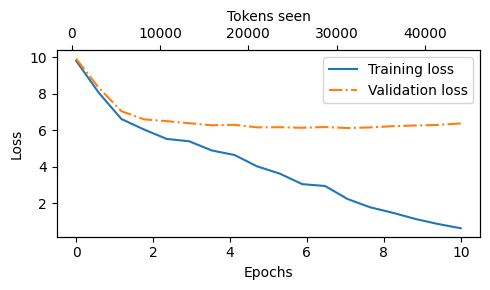

In [30]:
# Plot cross-entropy loss.
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
  fig, ax1 = plt.subplots(figsize=(5, 3))
  ax1.plot(epochs_seen, train_losses, label="Training loss")
  ax1.plot(
    epochs_seen, val_losses, linestyle="-.", label="Validation loss"
  )
  ax1.set_xlabel("Epochs")
  ax1.set_ylabel("Loss")
  ax1.legend(loc="upper right")
  ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
  ax2 = ax1.twiny()
  ax2.plot(tokens_seen, train_losses, alpha=0)
  ax2.set_xlabel("Tokens seen")
  fig.tight_layout()
  plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

In [31]:
# Temperature and top-k
model.to("cpu")
model.eval()

def generate(model, idx, max_new_tokens, context_size,
  temperature=0.0, top_k=None, eos_id=None):
  for _ in range(max_new_tokens):
    idx_cond = idx[:, -context_size:]
    with torch.no_grad():
      logits = model(idx_cond)
    logits = logits[:, -1, :]
    if top_k is not None:
      top_logits, _ = torch.topk(logits, top_k)
      min_val = top_logits[:, -1]
      logits = torch.where(
        logits < min_val,
        torch.tensor(float('-inf')).to(logits.device),
        logits
      )
    if temperature > 0.0:
      logits = logits / temperature
      probs = torch.softmax(logits, dim=-1)
      idx_next = torch.multinomial(probs, num_samples=1)
    else:
      idx_next = torch.argmax(logits, dim=-1, keepdim=True)
    if idx_next == eos_id:
      break
    idx = torch.cat((idx, idx_next), dim=1)
  return idx

torch.manual_seed(123)
token_ids = generate(
  model=model,
  idx=text_to_token_ids("Every effort moves you", tokenizer),
  max_new_tokens=15,
  context_size=GPT_CONFIG_124M["context_length"],
  top_k=25,
  temperature=1.4
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you?"
His up surprise. And whenever his glory, when by his head


In [32]:
# Save and Load model
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
  },
 "model_and_optimizer.pth"
)

checkpoint = torch.load("model_and_optimizer.pth", map_location=device)
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train();

In [33]:
# Download and load OpenAI weights for GPT-2 (Optional)

import urllib.request
import os

url = (
  "https://raw.githubusercontent.com/rasbt/"
  "LLMs-from-scratch/main/ch05/"
  "01_main-chapter-code/gpt_download.py"
)
filename = url.split('/')[-1]

# Check if gpt_download.py exists, if not, download it
if not os.path.exists(filename):
    urllib.request.urlretrieve(url, filename)

from gpt_download import download_and_load_gpt2

models_dir = "gpt2"
# Check if the models_dir (gpt2) exists, if not, download the models
if not os.path.exists(models_dir):
    settings, params = download_and_load_gpt2(
      model_size="124M", models_dir=models_dir
    )
else:
    print(f"GPT-2 models already downloaded in '{models_dir}'. Skipping download.")
    # If models are already downloaded, we need to load them to get settings and params
    # This part needs to be handled carefully as download_and_load_gpt2 also does the loading.
    # For now, assuming if directory exists, they are loaded later or manually.
    # For a complete solution, you'd load from the existing directory.
    # As an intermediate step, we can re-download the script and rely on it to load if it finds files.
    # However, the original download_and_load_gpt2 already handles this internally if files exist.
    # So, the initial check for the script is more important.
    settings, params = download_and_load_gpt2(
      model_size="124M", models_dir=models_dir
    )


checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 240kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:00<00:00, 2.97MiB/s]
hparams.json: 100%|██████████| 90.0/90.0 [00:00<00:00, 174kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 498M/498M [00:35<00:00, 13.9MiB/s]
model.ckpt.index: 100%|██████████| 5.21k/5.21k [00:00<00:00, 5.73MiB/s]
model.ckpt.meta: 100%|██████████| 471k/471k [00:00<00:00, 1.84MiB/s]
vocab.bpe: 100%|██████████| 456k/456k [00:00<00:00, 1.96MiB/s]


In [34]:
print("Settings:", settings)
print("Parameter dictionary keys:", params.keys())
model_configs = {
  "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
  "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
  "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
  "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}
model_name = "gpt2-small (124M)"
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])
NEW_CONFIG.update({"context_length": 1024})
NEW_CONFIG.update({"qkv_bias": True})
gpt = GPTModel(NEW_CONFIG)
gpt.eval()

def assign(left, right):
  if left.shape != right.shape:
    raise ValueError(f"Shape mismatch. Left: {left.shape}, "
       "Right: {right.shape}"
  )
  return torch.nn.Parameter(torch.tensor(right))

Settings: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
Parameter dictionary keys: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


In [35]:
import numpy as np

def load_weights_into_gpt(gpt, params):
  gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
  gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])

  for b in range(len(params["blocks"])):
    q_w, k_w, v_w = np.split(
    (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
    gpt.trf_blocks[b].att.W_query.weight = assign(
    gpt.trf_blocks[b].att.W_query.weight, q_w.T)
    gpt.trf_blocks[b].att.W_key.weight = assign(
    gpt.trf_blocks[b].att.W_key.weight, k_w.T)
    gpt.trf_blocks[b].att.W_value.weight = assign(
    gpt.trf_blocks[b].att.W_value.weight, v_w.T)
    q_b, k_b, v_b = np.split(
    (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
    gpt.trf_blocks[b].att.W_query.bias = assign(
    gpt.trf_blocks[b].att.W_query.bias, q_b)
    gpt.trf_blocks[b].att.W_key.bias = assign(
    gpt.trf_blocks[b].att.W_key.bias, k_b)
    gpt.trf_blocks[b].att.W_value.bias = assign(
    gpt.trf_blocks[b].att.W_value.bias, v_b)
    gpt.trf_blocks[b].att.out_proj.weight = assign(
    gpt.trf_blocks[b].att.out_proj.weight,
    params["blocks"][b]["attn"]["c_proj"]["w"].T)
    gpt.trf_blocks[b].att.out_proj.bias = assign(
    gpt.trf_blocks[b].att.out_proj.bias,
    params["blocks"][b]["attn"]["c_proj"]["b"])
    gpt.trf_blocks[b].ff.layers[0].weight = assign(
    gpt.trf_blocks[b].ff.layers[0].weight,
    params["blocks"][b]["mlp"]["c_fc"]["w"].T)
    gpt.trf_blocks[b].ff.layers[0].bias = assign(
    gpt.trf_blocks[b].ff.layers[0].bias,
    params["blocks"][b]["mlp"]["c_fc"]["b"])
    gpt.trf_blocks[b].ff.layers[2].weight = assign(
    gpt.trf_blocks[b].ff.layers[2].weight,
    params["blocks"][b]["mlp"]["c_proj"]["w"].T)
    gpt.trf_blocks[b].ff.layers[2].bias = assign(
    gpt.trf_blocks[b].ff.layers[2].bias,
    params["blocks"][b]["mlp"]["c_proj"]["b"])
    gpt.trf_blocks[b].norm1.scale = assign(
    gpt.trf_blocks[b].norm1.scale,
    params["blocks"][b]["ln_1"]["g"])
    gpt.trf_blocks[b].norm1.shift = assign(
    gpt.trf_blocks[b].norm1.shift,
    params["blocks"][b]["ln_1"]["b"])
    gpt.trf_blocks[b].norm2.scale = assign(
    gpt.trf_blocks[b].norm2.scale,
    params["blocks"][b]["ln_2"]["g"])
    gpt.trf_blocks[b].norm2.shift = assign(
    gpt.trf_blocks[b].norm2.shift,
    params["blocks"][b]["ln_2"]["b"])
  gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
  gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
  gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])

load_weights_into_gpt(gpt, params)
gpt.to(device)
torch.manual_seed(123)
token_ids = generate(
  model=gpt,
  idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
  max_new_tokens=25,
  context_size=NEW_CONFIG["context_length"],
  top_k=50,
  temperature=1.5
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you as far as the hand can go until the end of your turn unless something happens

This would remove you from a battle


In [36]:
# Fine-tune for Classification : Classification Head

import urllib.request
import zipfile
import os
from pathlib import Path
url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"

def download_and_unzip_spam_data(
  url, zip_path, extracted_path, data_file_path):
  if data_file_path.exists() :
    print(f"{data_file_path} already exists. Skipping download "
    "and extraction."
    )
    return
  with urllib.request.urlopen(url) as response:
    with open(zip_path, "wb") as out_file:
      out_file.write(response.read())

  with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extracted_path)

  original_file_path = Path(extracted_path) / "SMSSpamCollection"
  os.rename(original_file_path, data_file_path)
  print(f"File downloaded and saved as {data_file_path}")

download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)

import pandas as pd
df = pd.read_csv(
 data_file_path, sep="\t", header=None, names=["Label", "Text"]
)
print(df["Label"].value_counts())

File downloaded and saved as sms_spam_collection/SMSSpamCollection.tsv
Label
ham     4825
spam     747
Name: count, dtype: int64


In [37]:
def create_balanced_dataset(df):
  num_spam = df[df["Label"] == "spam"].shape[0]
  ham_subset = df[df["Label"] == "ham"].sample(
    num_spam, random_state=123
  )
  balanced_df = pd.concat([
    ham_subset, df[df["Label"] == "spam"]
  ])
  return balanced_df

balanced_df = create_balanced_dataset(df)
print(balanced_df["Label"].value_counts())
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})

Label
ham     747
spam    747
Name: count, dtype: int64


In [38]:
def random_split(df, train_frac, validation_frac):

  df = df.sample(
    frac=1, random_state=123
  ).reset_index(drop=True)
  train_end = int(len(df) * train_frac)
  validation_end = train_end + int(len(df) * validation_frac)

  train_df = df[:train_end]
  validation_df = df[train_end:validation_end]
  test_df = df[validation_end:]
  return train_df, validation_df, test_df

train_df, validation_df, test_df = random_split(
 balanced_df, 0.7, 0.1)
train_df.to_csv("train.csv", index=None)
validation_df.to_csv("validation.csv", index=None)
test_df.to_csv("test.csv", index=None)

In [39]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


In [40]:
import torch
from torch.utils.data import Dataset
class SpamDataset(Dataset):
  def __init__(self, csv_file, tokenizer, max_length=None,
      pad_token_id=50256):
    self.data = pd.read_csv(csv_file)

    self.encoded_texts = [
      tokenizer.encode(text) for text in self.data["Text"]
    ]
    if max_length is None:
      # If max_length is None, calculate it from the current dataset
      self.max_length = self._longest_encoded_length()
    else:
      # Otherwise, use the provided max_length
      self.max_length = max_length

    # Apply truncation and padding based on self.max_length
    self.encoded_texts = [
      encoded_text[:self.max_length]
      for encoded_text in self.encoded_texts
    ]

    self.encoded_texts = [
      encoded_text + [pad_token_id] *
      (self.max_length - len(encoded_text))
      for encoded_text in self.encoded_texts
    ]

  def __getitem__(self, index):
    encoded = self.encoded_texts[index]
    label = self.data.iloc[index]["Label"]
    return (
      torch.tensor(encoded, dtype=torch.long),
      torch.tensor(label, dtype=torch.long)
    )

  def __len__(self):
    return len(self.data)

  def _longest_encoded_length(self):
    max_length = 0
    for encoded_text in self.encoded_texts:
      encoded_length = len(encoded_text)
      if encoded_length > max_length:
        max_length = encoded_length
    return max_length

train_dataset = SpamDataset(
  csv_file="train.csv",
  max_length=None,
  tokenizer=tokenizer
)
print(train_dataset.max_length)
val_dataset = SpamDataset(
  csv_file="validation.csv",
  max_length=train_dataset.max_length,
  tokenizer=tokenizer
)
test_dataset = SpamDataset(
  csv_file="test.csv",
  max_length=train_dataset.max_length,
  tokenizer=tokenizer
)

from torch.utils.data import DataLoader
num_workers = 0
batch_size = 8
torch.manual_seed(123)
train_loader = DataLoader(
  dataset=train_dataset,
  batch_size=batch_size,
  shuffle=True,
  num_workers=num_workers,
  drop_last=True,
)
val_loader = DataLoader(
  dataset=val_dataset,
  batch_size=batch_size,
  num_workers=num_workers,
  drop_last=False,
)
test_loader = DataLoader(
  dataset=test_dataset,
  batch_size=batch_size,
  num_workers=num_workers,
  drop_last=False,
)

for input_batch, target_batch in train_loader:
  pass
print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")


120
130 training batches
19 validation batches
38 test batches


In [41]:
CHOOSE_MODEL = "gpt2-small (124M)"
INPUT_PROMPT = "Every effort moves"

BASE_CONFIG = {
  "vocab_size": 50257,
  "context_length": 1024,
  "drop_rate": 0.0,
  "qkv_bias": True
}
model_configs = {
  "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
  "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
  "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
  "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(
  model_size=model_size, models_dir="gpt2"
)
model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval()

File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json
File already exists and is up-to-date: gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [42]:
text_1 = "Every effort moves you"
token_ids = generate_text_simple(
  model=model,
  idx=text_to_token_ids(text_1, tokenizer),
  max_new_tokens=15,
  context_size=BASE_CONFIG["context_length"]
)
print(token_ids_to_text(token_ids, tokenizer))

text_2 = (
 "Is the following text 'spam'? Answer with 'yes' or 'no':"
 " 'You are a winner you have been specially"
 " selected to receive $1000 cash or a $2000 award.'"
)
token_ids = generate_text_simple(
  model=model,
  idx=text_to_token_ids(text_2, tokenizer),
  max_new_tokens=23,
  context_size=BASE_CONFIG["context_length"]
)
print(token_ids_to_text(token_ids, tokenizer))
# print(model)
for param in model.parameters():
  param.requires_grad = False

Every effort moves you forward.

The first step is to understand the importance of your work
Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.'

The following text 'spam'? Answer with 'yes' or 'no': 'You are a winner


In [43]:
torch.manual_seed(123)
num_classes = 2
model.out_head = torch.nn.Linear(
  in_features=BASE_CONFIG["emb_dim"],
  out_features=num_classes
)

# Ensure the new head is on the same device as the rest of the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for param in model.trf_blocks[-1].parameters():
  param.requires_grad = True
for param in model.final_norm.parameters():
  param.requires_grad = True

In [44]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

def calc_loss_batch(input_batch, target_batch, model, device):
  input_batch = input_batch.to(device)
  target_batch = target_batch.to(device)
  logits = model(input_batch)[:, -1, :]
  loss = torch.nn.functional.cross_entropy(logits, target_batch)
  return loss

def calc_loss_loader(data_loader, model, device, num_batches=None):
  total_loss = 0.
  if len(data_loader) == 0:
    return float("nan")
  elif num_batches is None:
    num_batches = len(data_loader)
  else:
    num_batches = min(num_batches, len(data_loader))
  for i, (input_batch, target_batch) in enumerate(data_loader):
    if i < num_batches:
      loss = calc_loss_batch(
        input_batch, target_batch, model, device
      )
      total_loss += loss.item()
    else:
      break
  return total_loss / num_batches

with torch.no_grad():
  train_loss = calc_loss_loader(
    train_loader, model, device, num_batches=5
  )
  val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)
  test_loss = calc_loss_loader(test_loader, model, device, num_batches=5)
  print(f"Training loss: {train_loss:.3f}")
  print(f"Validation loss: {val_loss:.3f}")
  print(f"Test loss: {test_loss:.3f}")


Training loss: 2.183
Validation loss: 2.583
Test loss: 2.322


In [45]:
def calc_accuracy_batch(input_batch, target_batch, model, device):
  input_batch, target_batch = input_batch.to(device), target_batch.to(device)
  logits = model(input_batch)[:, -1, :]
  predicted_labels = torch.argmax(logits, dim=-1)
  correct_predictions = (predicted_labels == target_batch).sum().item()
  return correct_predictions

def calc_accuracy_loader(data_loader, model, device, num_batches=None):
  model.eval()
  correct_predictions, num_examples = 0, 0
  if num_batches is None:
    num_batches = len(data_loader)
  else:
    num_batches = min(num_batches, len(data_loader))
  for i, (input_batch, target_batch) in enumerate(data_loader):
    if i < num_batches:
      num_examples += input_batch.shape[0]
      with torch.no_grad():
        correct_predictions += calc_accuracy_batch(
          input_batch, target_batch, model, device
        )
    else:
      break
  return correct_predictions / num_examples

def train_classifier_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs, eval_freq, eval_iter):
  train_losses, val_losses, train_accs, val_accs = [], [], [], []
  examples_seen, global_step = 0, -1

  for epoch in range(num_epochs):
    model.train()

    for input_batch, target_batch in train_loader:
      optimizer.zero_grad()
      loss = calc_loss_batch(
        input_batch, target_batch, model, device
      )
      loss.backward()
      optimizer.step()
      examples_seen += input_batch.shape[0]
      global_step += 1

      if global_step % eval_freq == 0:
        train_loss, val_loss = evaluate_model(
        model, train_loader, val_loader, device, eval_iter)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        print(f"Ep {epoch+1} (Step {global_step:06d}): "
          f"Train loss {train_loss:.3f}, "
          f"Val loss {val_loss:.3f}"
        )
    train_accuracy = calc_accuracy_loader(
      train_loader, model, device, num_batches=eval_iter
    )
    val_accuracy = calc_accuracy_loader(
      val_loader, model, device, num_batches=eval_iter
    )
    print(f"Training accuracy: {train_accuracy*100:.2f}% | ", end="")
    print(f"Validation accuracy: {val_accuracy*100:.2f}%")
    train_accs.append(train_accuracy)
    val_accs.append(val_accuracy)
  return train_losses, val_losses, train_accs, val_accs, examples_seen

def evaluate_model(model, train_loader, val_loader, device, eval_iter):
  model.eval()
  with torch.no_grad():
    train_loss = calc_loss_loader(
      train_loader, model, device, num_batches=eval_iter
    )
    val_loss = calc_loss_loader(
      val_loader, model, device, num_batches=eval_iter
    )
  model.train()
  return train_loss, val_loss

import time
start_time = time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)
num_epochs = 5
train_losses, val_losses, train_accs, val_accs, examples_seen = \
  train_classifier_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=50,
    eval_iter=5
  )
end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.153, Val loss 2.392
Ep 1 (Step 000050): Train loss 0.617, Val loss 0.637
Ep 1 (Step 000100): Train loss 0.523, Val loss 0.557
Training accuracy: 70.00% | Validation accuracy: 72.50%
Ep 2 (Step 000150): Train loss 0.561, Val loss 0.489
Ep 2 (Step 000200): Train loss 0.419, Val loss 0.397
Ep 2 (Step 000250): Train loss 0.409, Val loss 0.353
Training accuracy: 82.50% | Validation accuracy: 85.00%
Ep 3 (Step 000300): Train loss 0.333, Val loss 0.320
Ep 3 (Step 000350): Train loss 0.340, Val loss 0.306
Training accuracy: 90.00% | Validation accuracy: 90.00%
Ep 4 (Step 000400): Train loss 0.136, Val loss 0.200
Ep 4 (Step 000450): Train loss 0.153, Val loss 0.132
Ep 4 (Step 000500): Train loss 0.222, Val loss 0.137
Training accuracy: 100.00% | Validation accuracy: 97.50%
Ep 5 (Step 000550): Train loss 0.207, Val loss 0.143
Ep 5 (Step 000600): Train loss 0.083, Val loss 0.074
Training accuracy: 100.00% | Validation accuracy: 97.50%
Training completed in 1.02 mi

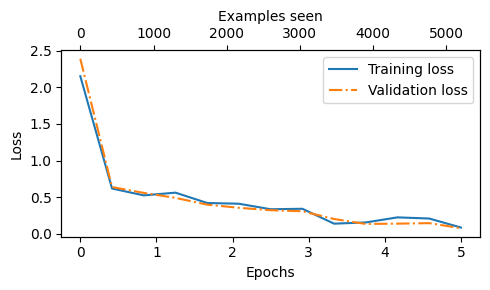

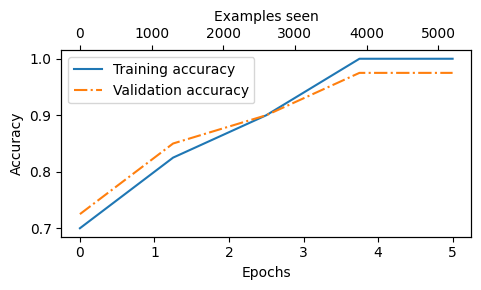

In [46]:
import matplotlib.pyplot as plt
def plot_values(
  epochs_seen, examples_seen, train_values, val_values,
  label="loss"):
  fig, ax1 = plt.subplots(figsize=(5, 3))

  ax1.plot(epochs_seen, train_values, label=f"Training {label}")
  ax1.plot(
    epochs_seen, val_values, linestyle="-.",
    label=f"Validation {label}"
  )
  ax1.set_xlabel("Epochs")
  ax1.set_ylabel(label.capitalize())
  ax1.legend()

  ax2 = ax1.twiny()
  ax2.plot(examples_seen, train_values, alpha=0)
  ax2.set_xlabel("Examples seen")
  fig.tight_layout()
  plt.savefig(f"{label}-plot.pdf")
  plt.show()
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))
plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))
plot_values(
  epochs_tensor, examples_seen_tensor, train_accs, val_accs,
  label="accuracy"
)

In [47]:
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)
print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 97.21%
Validation accuracy: 97.32%
Test accuracy: 95.67%


In [48]:
def classify_review(
    text, model, tokenizer, device, max_length=None,
    pad_token_id=50256):
  model.eval()
  input_ids = tokenizer.encode(text)
  supported_context_length = model.pos_emb.weight.shape[1]
  input_ids = input_ids[:min(
    max_length, supported_context_length
  )]
  input_ids += [pad_token_id] * (max_length - len(input_ids))

  input_tensor = torch.tensor(
    input_ids, device=device
  ).unsqueeze(0)

  with torch.no_grad():
    logits = model(input_tensor)[:, -1, :]
  predicted_label = torch.argmax(logits, dim=-1).item()
  return "spam" if predicted_label == 1 else "not spam"

text_1 = (
 "You are a winner you have been specially"
 " selected to receive $1000 cash or a $2000 award."
)
print(classify_review(
  text_1, model, tokenizer, device, max_length=train_dataset.max_length
))

text_2 = (
 "Hey, just wanted to check if we're still on"
 " for dinner tonight? Let me know!"
)
print(classify_review(
  text_2, model, tokenizer, device, max_length=train_dataset.max_length
))

torch.save(model.state_dict(), "review_classifier.pth")
model_state_dict = torch.load("review_classifier.pth", map_location=device)
model.load_state_dict(model_state_dict)

spam
not spam


<All keys matched successfully>

In [49]:
# Instruction Fine-tuning

import json
import os
import urllib
def download_and_load_file(file_path, url):
  if not os.path.exists(file_path):
    with urllib.request.urlopen(url) as response:
      text_data = response.read().decode("utf-8")
    with open(file_path, "w", encoding="utf-8") as file:
      file.write(text_data)
  else:
    with open(file_path, "r", encoding="utf-8") as file:
      text_data = file.read()
  with open(file_path, "r") as file:
    data = json.load(file)
  return data

file_path = "instruction-data.json"
url = (
  "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
  "/main/ch07/01_main-chapter-code/instruction-data.json"
)
data = download_and_load_file(file_path, url)
print("Number of entries:", len(data))

def format_input(entry):
  instruction_text = (
    f"Below is an instruction that describes a task. "
    f"Write a response that appropriately completes the request."
    f"\n\n### Instruction:\n{entry['instruction']}"
  )

  input_text = (
    f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""
  )
  return instruction_text + input_text

model_input = format_input(data[999])
desired_response = f"\n\n### Response:\n{data[999]['output']}"
print(model_input + desired_response)

train_portion = int(len(data) * 0.85)
test_portion = int(len(data) * 0.1)
val_portion = len(data) - train_portion - test_portion
train_data = data[:train_portion]
test_data = data[train_portion:train_portion + test_portion]
val_data = data[train_portion + test_portion:]
print("Training set length:", len(train_data))
print("Validation set length:", len(val_data))
print("Test set length:", len(test_data))

Number of entries: 1100
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What is an antonym of 'complicated'?

### Response:
An antonym of 'complicated' is 'simple'.
Training set length: 935
Validation set length: 55
Test set length: 110


In [50]:
import torch
from torch.utils.data import Dataset
class InstructionDataset(Dataset):
  def __init__(self, data, tokenizer):
    self.data = data
    self.encoded_texts = []
    for entry in data:
      instruction_plus_input = format_input(entry)
      response_text = f"\n\n### Response:\n{entry['output']}"
      full_text = instruction_plus_input + response_text
      self.encoded_texts.append(
        tokenizer.encode(full_text)
      )

  def __getitem__(self, index):
    return self.encoded_texts[index]

  def __len__(self):
    return len(self.data)

def custom_collate_draft_1(
  batch,
  pad_token_id=50256,
  device="cpu"
):
  batch_max_length = max(len(item)+1 for item in batch)
  inputs_lst = []
  for item in batch:
    new_item = item.copy()
    new_item += [pad_token_id]

    padded = (
      new_item + [pad_token_id] *
      (batch_max_length - len(new_item))
    )
    inputs = torch.tensor(padded[:-1])
    inputs_lst.append(inputs)
  inputs_tensor = torch.stack(inputs_lst).to(device)
  return inputs_tensor

inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]
batch = (
 inputs_1,
 inputs_2,
 inputs_3
)
print(custom_collate_draft_1(batch))

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])


In [51]:
def custom_collate_fn(
  batch,
  pad_token_id=50256,
  ignore_index=-100,
  allowed_max_length=None,
  device="cpu"
):
  batch_max_length = max(len(item)+1 for item in batch)
  inputs_lst, targets_lst = [], []
  for item in batch:
    new_item = item.copy()
    new_item += [pad_token_id]

    padded = (
      new_item + [pad_token_id] *
      (batch_max_length - len(new_item))
    )
    inputs = torch.tensor(padded[:-1])
    targets = torch.tensor(padded[1:])

    mask = targets == pad_token_id
    indices = torch.nonzero(mask).squeeze()
    if indices.numel() > 1:
      targets[indices[1:]] = ignore_index
    if allowed_max_length is not None:
      inputs = inputs[:allowed_max_length]
      targets = targets[:allowed_max_length]
    inputs_lst.append(inputs)
    targets_lst.append(targets)
  inputs_tensor = torch.stack(inputs_lst).to(device)
  targets_tensor = torch.stack(targets_lst).to(device)
  return inputs_tensor, targets_tensor

inputs, targets = custom_collate_fn(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


In [52]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# if torch.backends.mps.is_available():
# device = torch.device("mps")"
print("Device:", device)
from functools import partial
customized_collate_fn = partial(
  custom_collate_fn,
  device=device,
  allowed_max_length=1024
)

from torch.utils.data import DataLoader
num_workers = 0
batch_size = 8
torch.manual_seed(123)
train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
  train_dataset,
  batch_size=batch_size,
  collate_fn=customized_collate_fn,
  shuffle=True,
  drop_last=True,
  num_workers=num_workers
)

val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
  val_dataset,
  batch_size=batch_size,
  collate_fn=customized_collate_fn,
  shuffle=False,
  drop_last=False,
  num_workers=num_workers
)
test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
  test_dataset,
  batch_size=batch_size,
  collate_fn=customized_collate_fn,
  shuffle=False,
  drop_last=False,
  num_workers=num_workers
)

print("Train loader:")
for inputs, targets in train_loader:
  print(inputs.shape, targets.shape)

Device: cuda
Train loader:
torch.Size([8, 61]) torch.Size([8, 61])
torch.Size([8, 76]) torch.Size([8, 76])
torch.Size([8, 73]) torch.Size([8, 73])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 72]) torch.Size([8, 72])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 75]) torch.Size([8, 75])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 77]) torch.Size([8, 77])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 79]) torch.Size([8, 79])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 66]) torch.Size([8, 66])
torch.Size([8, 83]) torch.Size([8, 83])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8

In [53]:
BASE_CONFIG = {
  "vocab_size": 50257, # Vocabulary size
  "context_length": 1024, # Context length
  "drop_rate": 0.0, # Dropout rate
  "qkv_bias": True # Query-key-value bias
}
model_configs = {
  "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
  "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
  "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
  "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}
CHOOSE_MODEL = "gpt2-medium (355M)"
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])
model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(
  model_size=model_size,
  models_dir="gpt2"
)
model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval();

checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 160kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:00<00:00, 2.75MiB/s]
hparams.json: 100%|██████████| 91.0/91.0 [00:00<00:00, 200kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 1.42G/1.42G [01:48<00:00, 13.0MiB/s]
model.ckpt.index: 100%|██████████| 10.4k/10.4k [00:00<00:00, 22.4MiB/s]
model.ckpt.meta: 100%|██████████| 927k/927k [00:00<00:00, 2.39MiB/s]
vocab.bpe: 100%|██████████| 456k/456k [00:00<00:00, 1.82MiB/s]


In [54]:
torch.manual_seed(123)
input_text = format_input(val_data[0])

token_ids = generate(
  model=model,
  idx=text_to_token_ids(input_text, tokenizer),
  max_new_tokens=35,
  context_size=BASE_CONFIG["context_length"],
  eos_id=50256,
)
generated_text = token_ids_to_text(token_ids, tokenizer)
response_text = generated_text[len(input_text):].strip()
print(response_text)

### Response:

The chef cooks the meal every day.

### Instruction:

Convert the active sentence to passive: 'The chef cooks the


In [55]:
def calc_loss_batch(input_batch, target_batch, model, device):
  input_batch = input_batch.to(device)
  target_batch = target_batch.to(device)
  logits = model(input_batch)
  # Flatten logits and targets to calculate cross entropy across the sequence
  loss = torch.nn.functional.cross_entropy(
    logits.flatten(0, 1), target_batch.flatten()
  )
  return loss

model.to(device)
torch.manual_seed(123)
with torch.no_grad():
  train_loss = calc_loss_loader(
    train_loader, model, device, num_batches=5
  )
  val_loss = calc_loss_loader(
    val_loader, model, device, num_batches=5
  )
print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 3.82590913772583
Validation loss: 3.7619335651397705


In [56]:
import time
start_time = time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(
  model.parameters(), lr=0.00005, weight_decay=0.1
)
num_epochs = 2
train_losses, val_losses, tokens_seen = train_model_simple(
  model, train_loader, val_loader, optimizer, device,
  num_epochs=num_epochs, eval_freq=5, eval_iter=5,
  start_context=format_input(val_data[0]), tokenizer=tokenizer
)
end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.637, Val loss 2.626
Below is an instruction that describes a task. Write a response that appropriately completes the request.  ### Instruction: Convert the active sentence to passive: 'The chef cooks the meal every day.'  ### Response: ### Write a response that appropriately completes the request.  ### Instruction: ### Write a response that appropriately completes the request.  ### Response: ### Write a response that appropriately completes the request.  
Ep 1 (Step 000005): Train loss 1.174, Val loss 1.103
Below is an instruction that describes a task. Write a response that appropriately completes the request.  ### Instruction: Convert the active sentence to passive: 'The chef cooks the meal every day.'  ### Response: The chef cooks the meal every day.<|endoftext|>The following is a list of items that make good gifts for Cinna, who likes Modern, white items and dislikes Basic items.  Best Gifts for Cin
Ep 1 (Step 000010): Train loss 0.872, Val loss 0.9

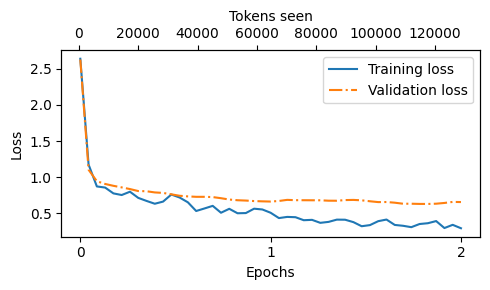

In [57]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

In [58]:
import torch
torch.manual_seed(123)
for entry in test_data[:3]:
  input_text = format_input(entry)
  token_ids = generate(
    model=model,
    idx=text_to_token_ids(input_text, tokenizer).to(device),
    max_new_tokens=256,
    context_size=BASE_CONFIG["context_length"],
    eos_id=50256
  )
  generated_text = token_ids_to_text(token_ids, tokenizer)

  response_text = (
    generated_text[len(input_text):]
    .replace("### Response:", "")
    .strip()
  )

  print(input_text)
  print(f"\nCorrect response:\n>> {entry['output']}")
  print(f"\nModel response:\n>> {response_text.strip()}")
  print("---------------------------------")

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.

Correct response:
>> The car is as fast as lightning.

Model response:
>> The car is as fast as a bullet.
---------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What type of cloud is typically associated with thunderstorms?

Correct response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model response:
>> The type of cloud associated with thunderstorms is a cumulus cloud.
---------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Name the author of 'Pride and Prejudice'.

Correct response:
>> Jane Austen.

Model response:
>> The author of 'Pride and Prejudice' i

In [59]:
from tqdm import tqdm

for i, entry in tqdm(enumerate(test_data), total=len(test_data)):
  input_text = format_input(entry)
  token_ids = generate(
    model=model,
    idx=text_to_token_ids(input_text, tokenizer).to(device),
    max_new_tokens=256,
    context_size=BASE_CONFIG["context_length"],
    eos_id=50256
  )
  generated_text = token_ids_to_text(token_ids, tokenizer)

  response_text = (
    generated_text[len(input_text):]
    .replace("### Response:", "")
    .strip()
  )
  test_data[i]["model_response"] = response_text

with open("instruction-data-with-response.json", "w") as file:
 json.dump(test_data, file, indent=4)

100%|██████████| 110/110 [01:09<00:00,  1.59it/s]


In [61]:
print(test_data[0])
import re
file_name = f"{re.sub(r'[ ()]', '', CHOOSE_MODEL) }-sft.pth"
torch.save(model.state_dict(), file_name)
print(f"Model saved as {file_name}")

{'instruction': 'Rewrite the sentence using a simile.', 'input': 'The car is very fast.', 'output': 'The car is as fast as lightning.', 'model_response': 'The car is as fast as a bullet.'}
Model saved as gpt2-medium355M-sft.pth


In [ ]:
# 1. Install zstd (required for Ollama extraction) and Ollama
!sudo apt-get update && sudo apt-get install -y zstd
!curl -fsSL https://ollama.com/install.sh | sh

# 2. Run the server in the background
import subprocess
import time
import os

# Check if ollama was installed before trying to run it
if os.path.exists('/usr/local/bin/ollama') or os.path.exists('/usr/bin/ollama'):
    subprocess.Popen(["ollama", "serve"])
    time.sleep(5) # Give the server a bit more time to start

    # 3. Pull Llama 3 and run the script
    !ollama pull llama3
    # Note: Ensure ollama_evaluate.py exists in your environment
    !python ollama_evaluate.py --file_path instruction-data-with-response.json
else:
    print("Ollama installation failed. Please check the logs above for errors.")

In [64]:
!wget https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch07/01_main-chapter-code/ollama_evaluate.py

--2026-03-16 03:22:36--  https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch07/01_main-chapter-code/ollama_evaluate.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3696 (3.6K) [text/plain]
Saving to: ‘ollama_evaluate.py’

ollama_evaluate.py  100%[===================>]   3.61K  --.-KB/s    in 0s      

2026-03-16 03:22:37 (68.2 MB/s) - ‘ollama_evaluate.py’ saved [3696/3696]



In [65]:
import subprocess
import time

# Install GPU detection utilities
!apt-get install -y pciutils lshw

# Start the Ollama server in the background
subprocess.Popen(["ollama", "serve"])

# Give the server a few seconds to initialize
time.sleep(3)

# Pull the Llama 3 model required by the script
!ollama pull llama3

In [ ]:
!python ollama_evaluate.py --file_path instruction-data-with-response.json

In [69]:
import re

with open('ollama_evaluate.py', 'r') as f:
    content = f.read()

# Increase timeout to 300 seconds to ensure the model has enough time to respond
updated_content = re.sub(r'timeout=60', 'timeout=300', content)

with open('ollama_evaluate.py', 'w') as f:
    f.write(updated_content)

print('Timeout in ollama_evaluate.py increased to 300 seconds.')

Timeout in ollama_evaluate.py increased to 300 seconds.


In [70]:
!python ollama_evaluate.py --file_path instruction-data-with-response.json

Ollama running: True
Scoring entries: 100% 110/110 [04:11<00:00,  2.29s/it]
Number of scores: 110 of 110
Average score: 50.39

